In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/brain_tumor_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  object 
 3   Tumor_Type           20000 non-null  object 
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  object 
 6   Histology            20000 non-null  object 
 7   Stage                20000 non-null  object 
 8   Symptom_1            20000 non-null  object 
 9   Symptom_2            20000 non-null  object 
 10  Symptom_3            20000 non-null  object 
 11  Radiation_Treatment  20000 non-null  object 
 12  Surgery_Performed    20000 non-null  object 
 13  Chemotherapy         20000 non-null  object 
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_Growth_Rate    20000 non-null 

In [153]:
df.head()

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


In [154]:
df.drop(columns=["Patient_ID"], inplace=True)

In [155]:
df.duplicated().sum()

np.int64(0)

In [156]:
num_cols = df.select_dtypes("number").columns.to_list()
cat_cols = df.select_dtypes("object").columns.to_list()

print(f"Numerical Columns: {num_cols}")
print(f"Categorical Columns: {cat_cols}")

Numerical Columns: ['Age', 'Tumor_Size', 'Survival_Rate', 'Tumor_Growth_Rate']
Categorical Columns: ['Gender', 'Tumor_Type', 'Location', 'Histology', 'Stage', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy', 'Family_History', 'MRI_Result', 'Follow_Up_Required']


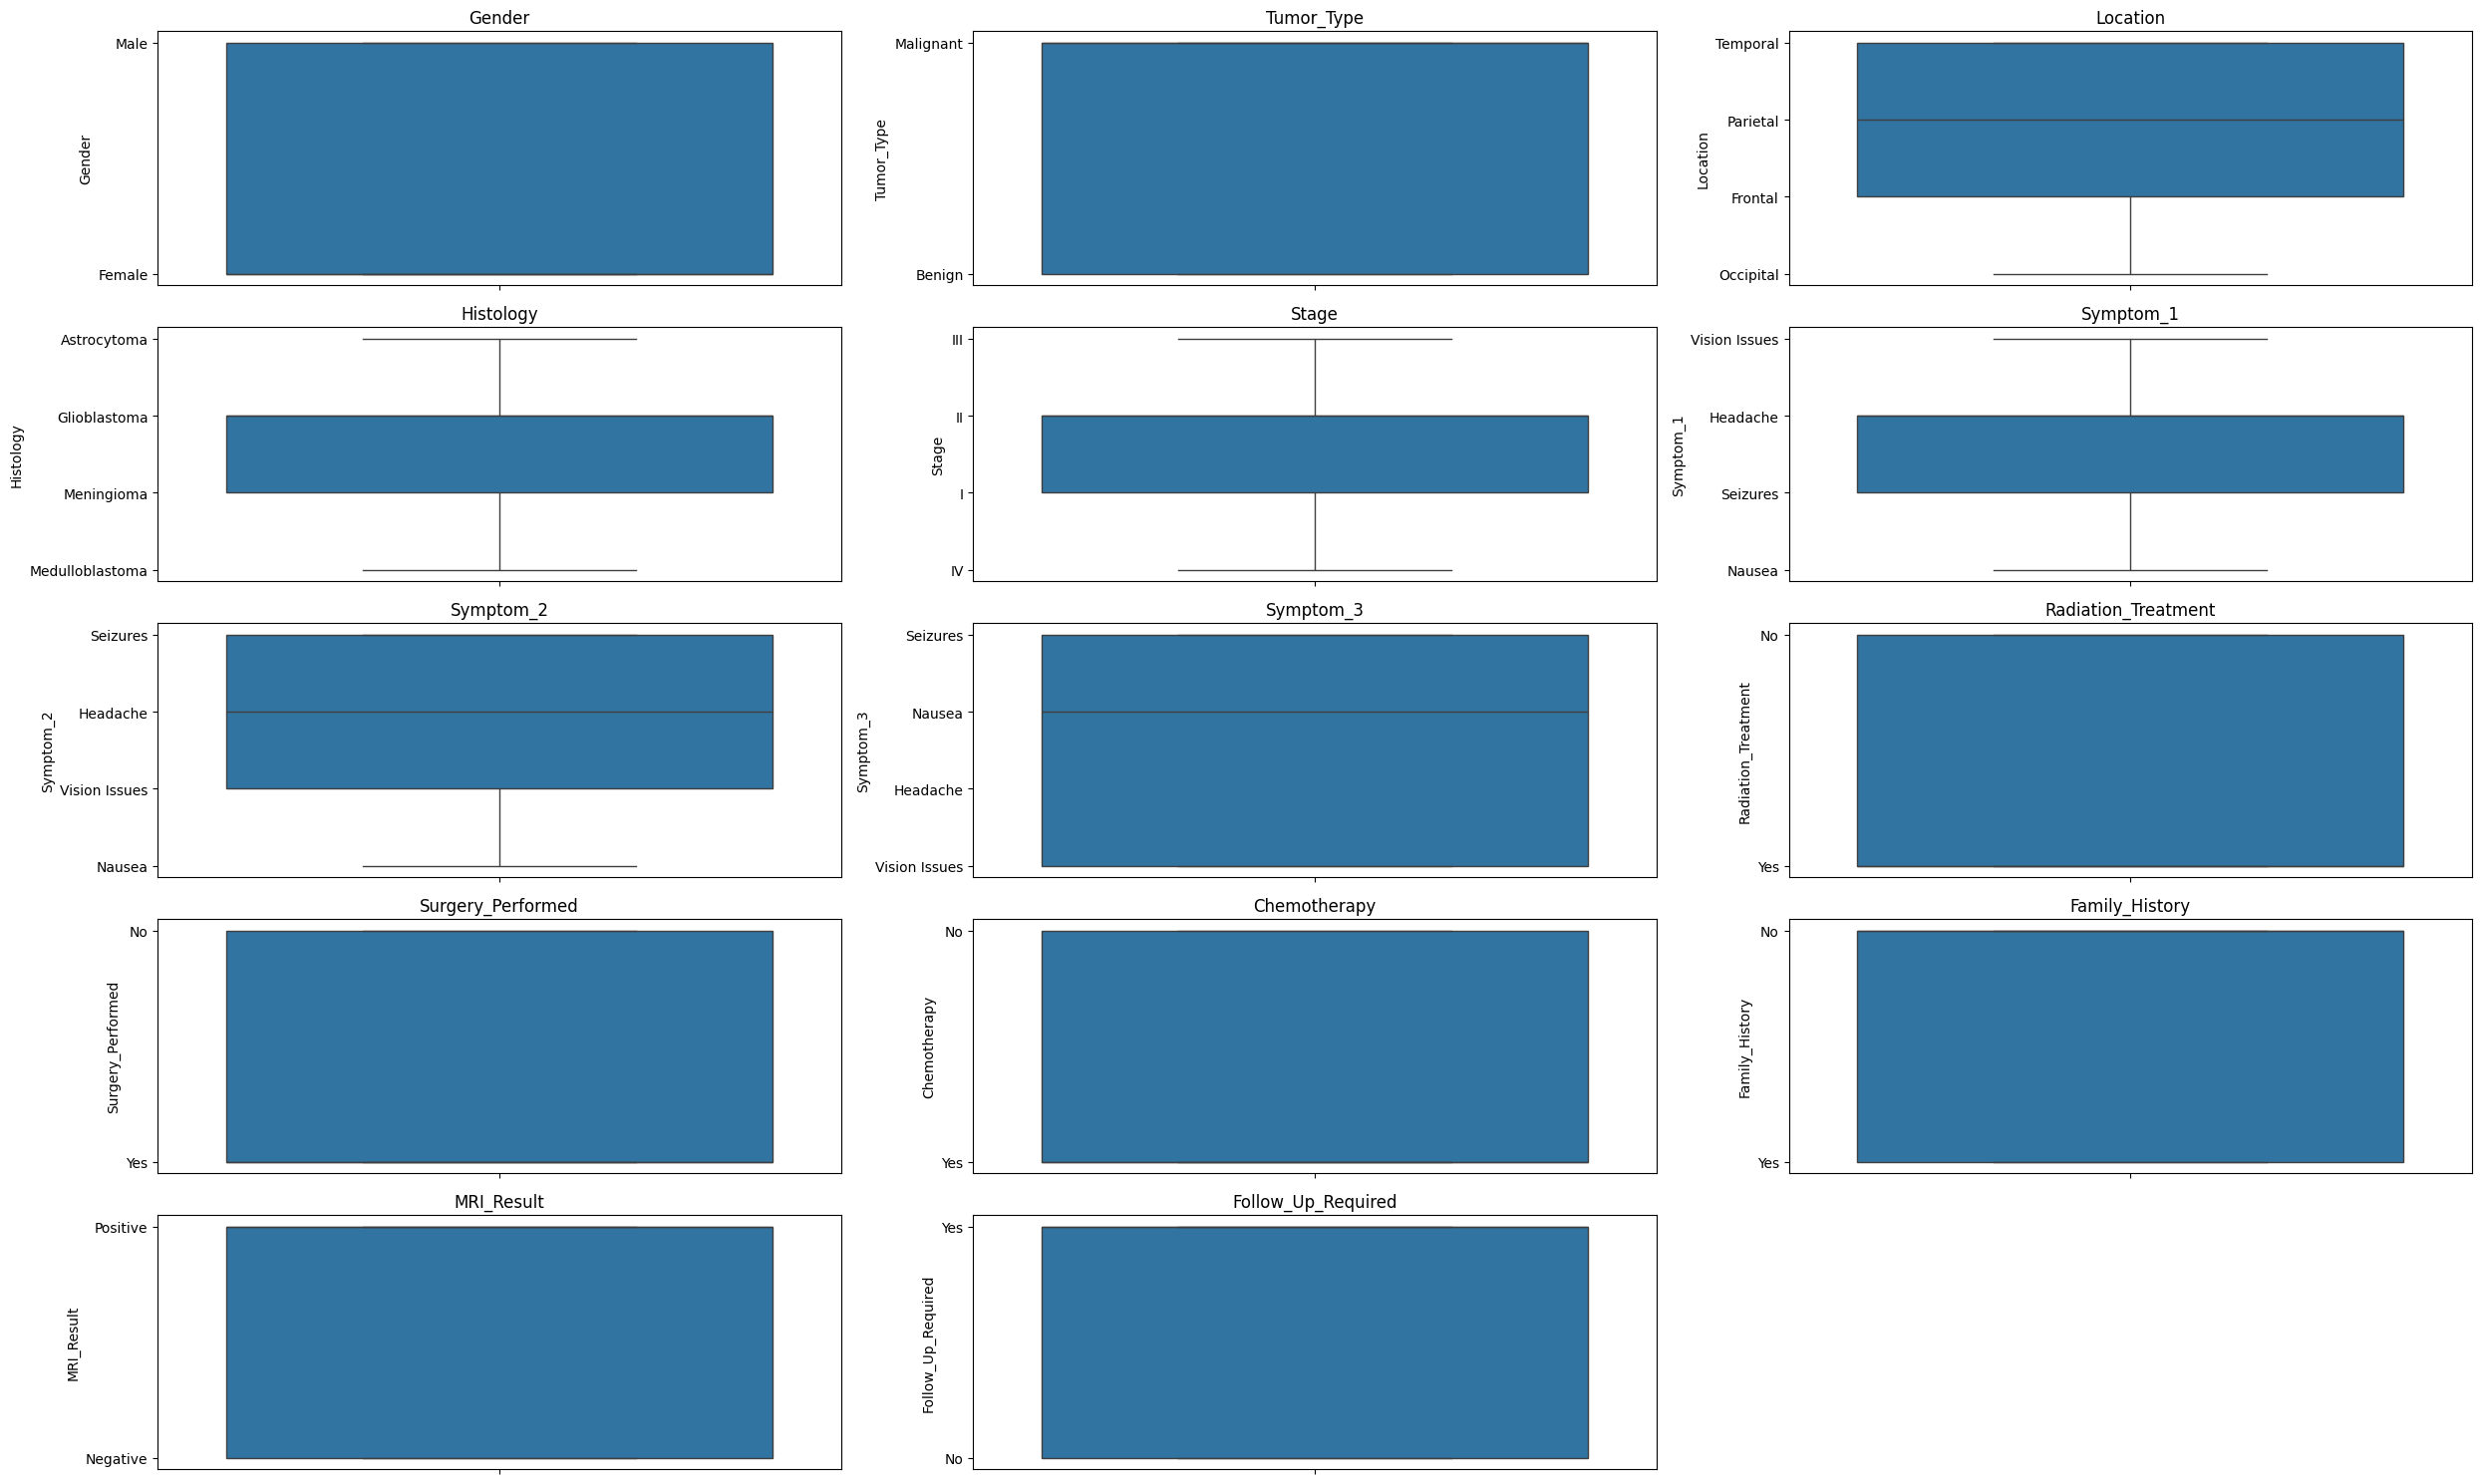

In [157]:
n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_rows*5, n_cols*5))
ax = ax.flatten()

for i, col in enumerate(cat_cols):

    ax[i].set_title(col)
    sns.boxplot(
        ax=ax[i],
        y=df[col],
    )

for j in range(len(cat_cols), n_rows*n_cols):
    fig.delaxes(ax[i+1])

plt.tight_layout()
plt.show()

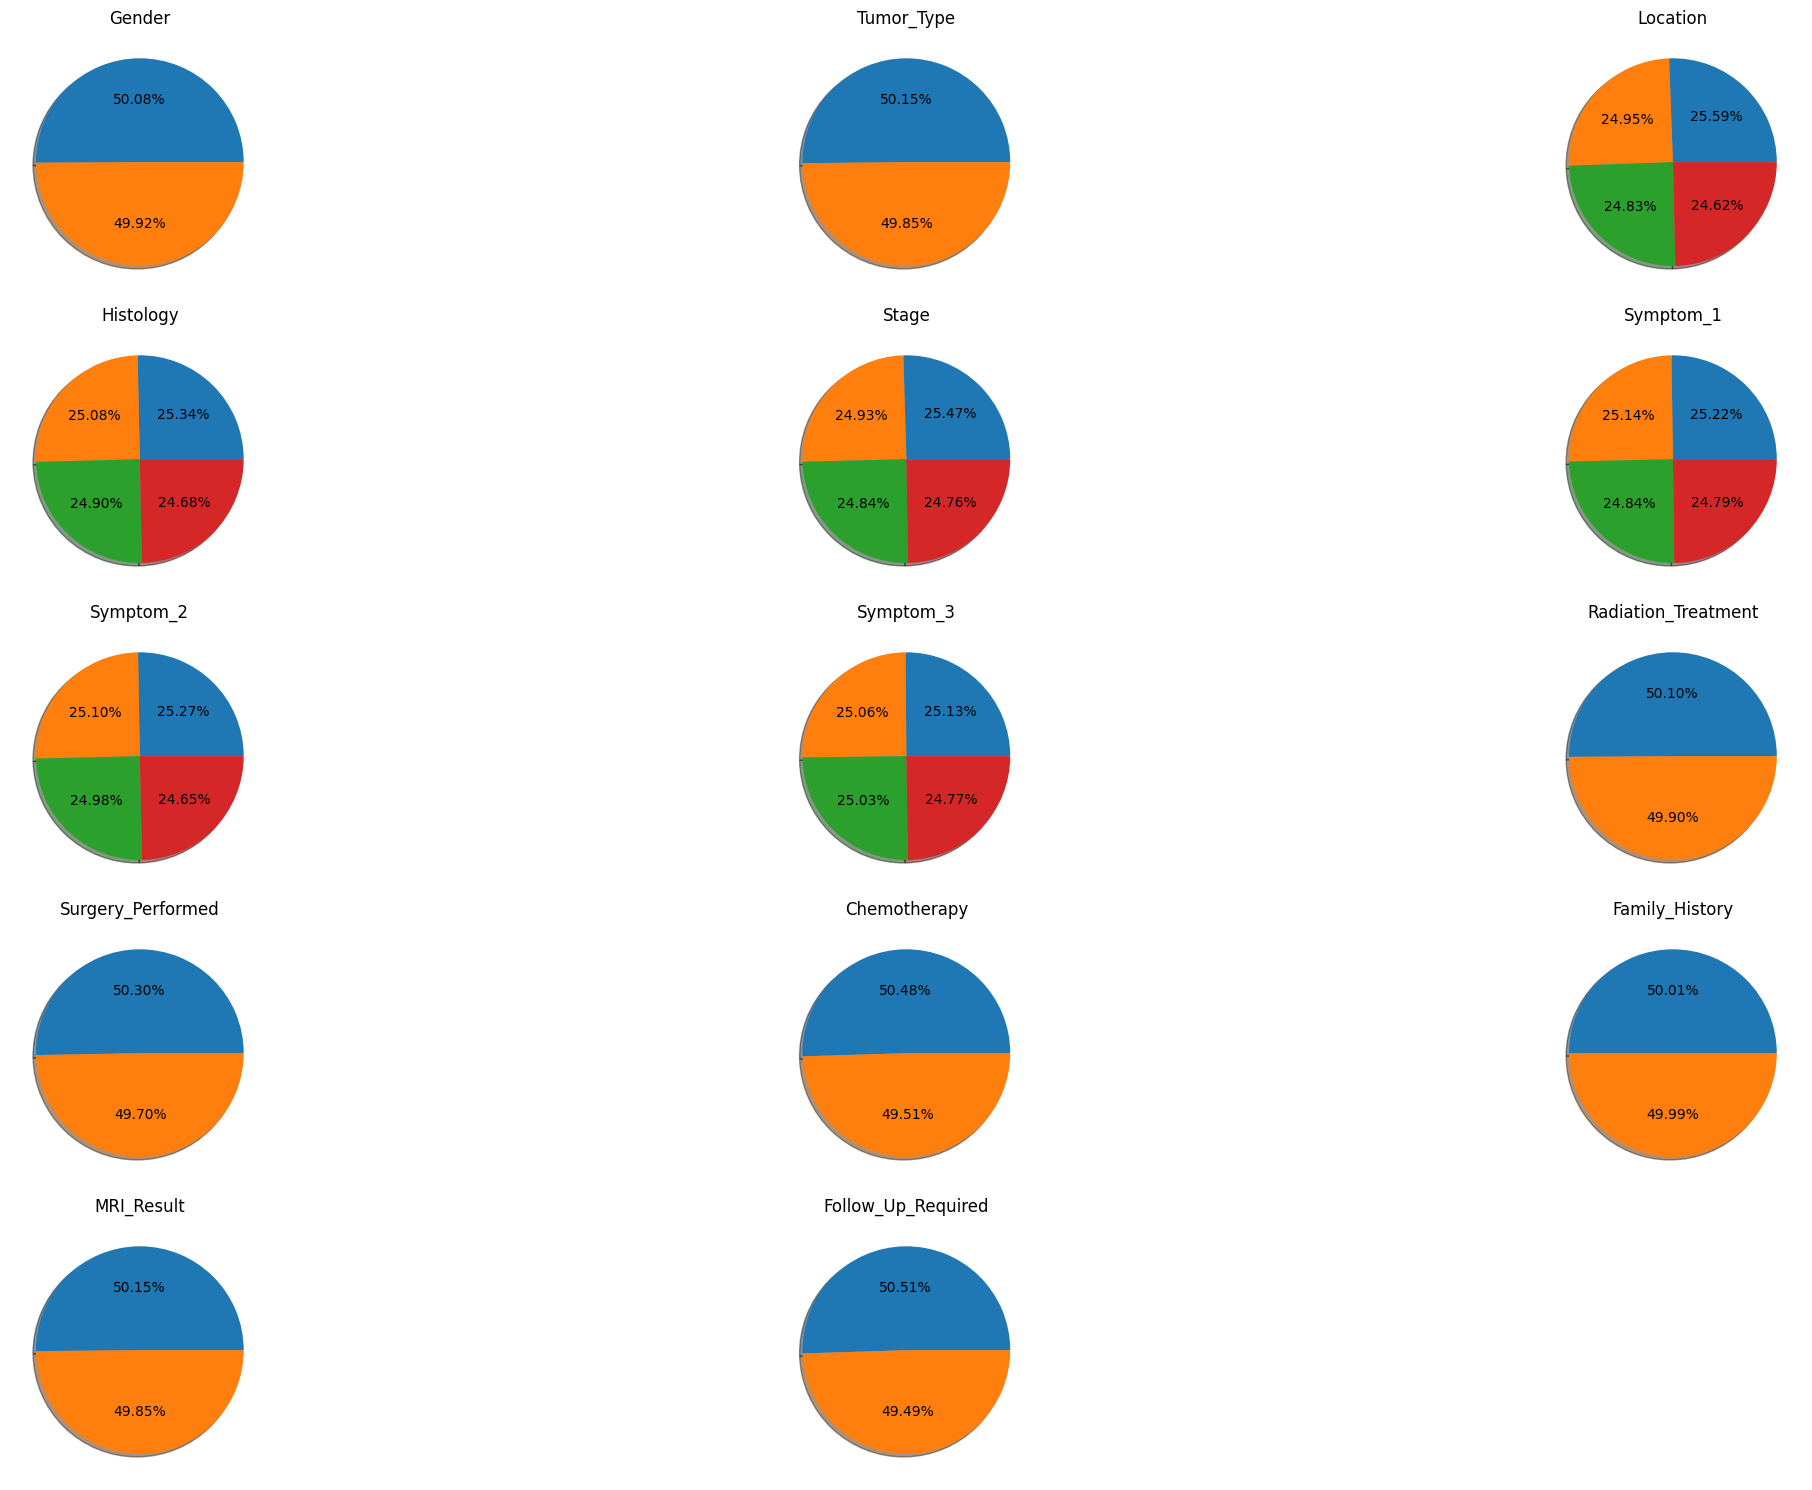

In [158]:
n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_rows*5, n_cols*5))
ax = ax.flatten()

for i, col in enumerate(cat_cols):
    data = df[col].value_counts()

    ax[i].set_title(col)
    ax[i].pie(
        x=data,
        autopct="%.2f%%",
        shadow=True,
    )

for j in range(len(cat_cols), n_rows*n_cols):
    fig.delaxes(ax[i+1])

plt.tight_layout()
plt.show()

In [159]:
def label_encode(df: pd.DataFrame):
    struct = dict()
    for col in df.select_dtypes("object").columns.tolist():
        unq = df[col].unique()
        unq_map = {v: k for k, v in enumerate(unq)}
        struct[col] = unq_map
        df[col] = df[col].map(unq_map)
    
    return df, struct

In [160]:
df_enc, struct = label_encode(df)

df_enc.head()

,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,73,0,0,5.375612,0,0,0,0,0,0,0,0,0,51.312579,0.111876,0,0,0
1,26,0,1,4.847098,1,1,1,1,1,1,1,1,1,46.373273,2.165736,1,0,0
2,31,0,1,5.588391,1,2,2,0,1,0,0,0,0,47.072221,1.884228,0,1,1
3,29,0,0,1.436600,0,3,3,0,0,2,1,0,1,51.853634,1.283342,1,1,1
4,54,1,1,2.417506,1,1,2,1,1,0,0,0,1,54.708987,2.069477,0,0,0


In [161]:
struct

{'Gender': {'Male': 0, 'Female': 1},
 'Tumor_Type': {'Malignant': 0, 'Benign': 1},
 'Location': {'Temporal': 0, 'Parietal': 1, 'Frontal': 2, 'Occipital': 3},
 'Histology': {'Astrocytoma': 0,
  'Glioblastoma': 1,
  'Meningioma': 2,
  'Medulloblastoma': 3},
 'Stage': {'III': 0, 'II': 1, 'I': 2, 'IV': 3},
 'Symptom_1': {'Vision Issues': 0, 'Headache': 1, 'Seizures': 2, 'Nausea': 3},
 'Symptom_2': {'Seizures': 0, 'Headache': 1, 'Vision Issues': 2, 'Nausea': 3},
 'Symptom_3': {'Seizures': 0, 'Nausea': 1, 'Headache': 2, 'Vision Issues': 3},
 'Radiation_Treatment': {'No': 0, 'Yes': 1},
 'Surgery_Performed': {'No': 0, 'Yes': 1},
 'Chemotherapy': {'No': 0, 'Yes': 1},
 'Family_History': {'No': 0, 'Yes': 1},
 'MRI_Result': {'Positive': 0, 'Negative': 1},
 'Follow_Up_Required': {'Yes': 0, 'No': 1}}

In [162]:
def train_test_split(X: pd.DataFrame, y: pd.DataFrame, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)
    
    n_samples = len(X)
    shuffle_indices = np.random.permutation(np.arange(n_samples))

    test_size = round(test_size * n_samples)
    train_size = test_size - n_samples

    train_indices = shuffle_indices[:train_size]
    test_indices = shuffle_indices[test_size:]

    X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
    y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]

    return [X_train, X_test, y_train, y_test]

In [163]:
X = df.drop(columns=["Tumor_Type"])
y = df.Tumor_Type

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

X_train.head()

,Age,Gender,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
10650,60,0,4.185355,0,2,1,3,1,1,0,0,1,94.739701,0.128492,0,0,0
2041,29,1,6.391747,0,2,2,3,2,0,1,0,1,49.751461,1.724219,1,0,1
8668,28,0,1.129997,1,1,3,0,0,3,1,1,1,95.452798,1.228702,1,0,0
1114,69,1,2.188328,0,0,1,0,1,2,1,0,0,92.178737,1.096059,0,1,0
13902,69,1,5.847122,2,0,1,1,3,0,1,0,0,90.654556,2.415105,0,1,0


In [164]:
y_train.head()

10650    0
2041     0
8668     0
1114     1
13902    0
Name: Tumor_Type, dtype: int64

In [165]:
def min_max_scaler(X: pd.DataFrame):
    return ((X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0)))

def std_scaler(X: pd.DataFrame):
    return ((X - X.mean(axis=0)) / X.std(axis=0))

In [166]:
X_train_mm_scaler = min_max_scaler(X_train)
X_test_mm_scaler = min_max_scaler(X_test)

X_train_mm_scaler.head()

,Age,Gender,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
10650,0.677966,0.0,0.387713,0.000000,0.666667,0.333333,1.000000,0.333333,0.333333,0.0,0.0,1.0,0.912353,0.008893,0.0,0.0,0.0
2041,0.152542,1.0,0.620071,0.000000,0.666667,0.666667,1.000000,0.666667,0.000000,1.0,0.0,1.0,0.162496,0.559699,1.0,0.0,1.0
8668,0.135593,0.0,0.065949,0.333333,0.333333,1.000000,0.000000,0.000000,1.000000,1.0,1.0,1.0,0.924239,0.388659,1.0,0.0,0.0
1114,0.830508,1.0,0.177403,0.000000,0.000000,0.333333,0.000000,0.333333,0.666667,1.0,0.0,0.0,0.869668,0.342874,0.0,1.0,0.0
13902,0.830508,1.0,0.562716,0.666667,0.000000,0.333333,0.333333,1.000000,0.000000,1.0,0.0,0.0,0.844263,0.798176,0.0,1.0,0.0


In [167]:
X_train_std_scaler = std_scaler(X_train)
X_test_std_scaler = std_scaler(X_test)

X_train_std_scaler.head()

,Age,Gender,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
10650,0.589166,-1.017529,-0.385379,-1.337359,0.449617,-0.438144,1.355419,-0.440520,-0.463741,-0.987454,-1.004385,1.005892,1.422249,-1.710862,-0.998376,-1.007402,-0.986960
2041,-1.209505,0.982528,0.421674,-1.337359,0.449617,0.456028,1.355419,0.446730,-1.364645,1.012453,-1.004385,1.005892,-1.196746,0.210987,1.001376,-1.007402,1.012959
8668,-1.267527,-1.017529,-1.502967,-0.439953,-0.443809,1.350200,-1.343275,-1.327769,1.338068,1.012453,0.995386,1.005892,1.463762,-0.385800,1.001376,-1.007402,-0.986960
1114,1.111361,0.982528,-1.115851,-1.337359,-1.337236,-0.438144,-1.343275,-0.440520,0.437164,1.012453,-1.004385,-0.993894,1.273163,-0.545552,-0.998376,0.992404,-0.986960
13902,1.111361,0.982528,0.222462,0.457453,-1.337236,-0.438144,-0.443710,1.333980,-1.364645,1.012453,-1.004385,-0.993894,1.184432,1.043070,-0.998376,0.992404,-0.986960


In [168]:
class KNN:
    def __init__(self, k:int, p:int, weight):
        self.k = k
        self.p = p
        self.weight = weight
    
    def _minkowksi_distance(self, X: pd.DataFrame, y: pd.DataFrame):
        return np.power(np.sum(np.abs(X - y) ** self.p), 1/self.p)

    def fit(self, X_train: pd.DataFrame, y_train: pd.DataFrame):
        self.X_train = X_train
        self.y_train = y_train
    
    def _get_nn(self, X_test: pd.DataFrame):
        distance = [self._minkowksi_distance(X_test, X) for X in self.X_train]
        k_idxs = np.argsort(distance)[:self.k]
        k_labels = [self.y_train[i] for i in k_idxs]
        k_distance = [distance[i] for i in k_idxs]

        if self.weight == "uniform":
            values, counts = np.unique(k_labels, return_counts=True)
            max_count = max(counts)
            candidate = values[counts == max_count]
            return np.random.choice(candidate)
        
        elif self.weight == "distance":
            weights = [1 / (d + 1e-5) for d in k_distance]
        elif callable(self.weight):
            weights = [self.weight(d) for d in k_distance]
        else:
            raise ValueError("Parameter 'weight' tidak ada yang cocok!")
        
        label_weight = dict()
        for label, weight in zip(k_labels, weights):
            label_weight[label] = label_weight.get(label, 0) + weight
        
        max_weight = max(label_weight.values())
        candidate = [label for label, weight in label_weight.items() if weight == max_weight]
        return np.random.choice(candidate)

    def predict(self, X_test: pd.DataFrame):
        preds = [self._get_nn(x) for x in X_test]
        return np.array(preds)

In [169]:
class EvaluationModel:
    def __init__(self, y_true: pd.DataFrame, y_pred: pd.DataFrame):
        self.y_true = y_true
        self.y_pred = y_pred

    def accuracy(self, y_pred, y_true):
        return np.sum(y_pred == y_true) / len(y_true)
    
    def pricision(self, TP, FP):
        return TP / (TP + FP) if (TP + FP) != 0 else 0
    
    def recall(self, TP, FN):
        return TP / (TP + FN) if (TP + FN) != 0 else 0
    
    def f1_score(self, TP, FP, FN):
        P = self.pricision(TP, FP)
        R = self.recall(TP, FN)

        return 2 * (P * R) / (P + R) if (P + R) != 0 else 0
    
    def make_report(self):
        cats = pd.Series(self.y_true).unique()

        reports = {"Categorical": [], "Precision": [], "Recall": [], "F1-Score": []}

        for cat in cats:
            # Confsion Matrix
            TP = np.sum((self.y_true == cat) & (self.y_pred == cat)) # Asli positif predict positif
            TN = np.sum((self.y_true != cat) & (self.y_pred != cat)) # Asli negatif predict negatif
            FP = np.sum((self.y_true != cat) & (self.y_pred == cat)) # Asli negatif predict negatif
            FN = np.sum((self.y_true == cat) & (self.y_pred != cat)) # Asli negatif predict positif

            # Calculation Matrix
            P = self.pricision(TP, FP)
            R = self.recall(TP, FN)
            F1 = self.f1_score(TP, FP, FN)

            # Append matrix
            reports["Categorical"].append(col)
            reports["Precision"].append(P)
            reports["Recall"].append(R)
            reports["F1-Score"].append(F1)

        accuracy = self.accuracy(self.y_pred, self.y_true)
        results = pd.DataFrame(reports)

        return results, accuracy

In [170]:
from IPython.display import display

def search_best_model(params: dict):
    models = list()

    for k in params["K"]:
        for p in params["P"]:
            for weight in params["Weight"]:
                for i, (train, test) in enumerate(params["Scaler"]):
                    # Initialization Model
                    model = KNN(k=k, p=p, weight=weight)
                    model.fit(X_train=train[:5000].to_numpy(), y_train=y_train[:5000].to_numpy())

                    preds = model.predict(X_test=test[:5000].to_numpy())

                    # Evaluation
                    eval_model = EvaluationModel(y_pred=preds, y_true=y_test[:5000].to_numpy())
                    results_df, accuracy = eval_model.make_report()

                    params_result = {
                        "K": k,
                        "P": p,
                        "weight": weight,
                        "Scaler": i
                    }

                    models.append({
                        "Params": params_result,
                        "Accuracy": accuracy,
                        "result_df": results_df
                    })

    result_df = sorted(models, key=lambda x: x["Accuracy"], reverse=True)
    for result in result_df:
        print(f"Params: {result["Params"]}")
        print(f"Accuracy: {result["Accuracy"]}")
        display(result["result_df"])

In [171]:
def custom_weight(d):
    return 1 / (d**2 + 1e-5)

params = {
    "K": range(3, 9),
    "P": range(1, 3),  
    "Weight": ["uniform", "distance", custom_weight],
    "Scaler": [(X_train_mm_scaler, X_test_mm_scaler), (X_train_std_scaler, X_test_std_scaler), (X_train, X_test)]
}

search_best_model(params)

KeyboardInterrupt: 